In [1]:
import os
from rich import print
from dotenv import load_dotenv
from huggingface_hub import login
from price_agent.data.items import Item
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

d:\ujjwal\the_capstone_project\.venv\Lib\site-packages\huggingface_hub\constants.py:310: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


In [2]:
LITE_MODE = True

load_dotenv(override=True)
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

2026-08-25 18:51:25,895 INFO httpx HTTP Request: GET https://huggingface.co/api/whoami-v2 "HTTP/1.1 200 OK"
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
2026-08-25 18:51:26,489 WARNING huggingface_hub._login Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:
username = "ujjwalsingh108"
dataset = f"{username}/items_lite" if LITE_MODE else f"{username}/items_full"

train, val, test = Item.from_hub(dataset)
items = train + val + test

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

2026-08-25 18:51:26,918 INFO httpx HTTP Request: HEAD https://huggingface.co/datasets/ujjwalsingh108/items_lite/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-08-25 18:51:27,028 INFO httpx HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/ujjwalsingh108/items_lite/457bd961c240529a681fe965e44297f6d98a19a8/README.md "HTTP/1.1 200 OK"
2026-08-25 18:51:27,327 INFO httpx HTTP Request: HEAD https://huggingface.co/datasets/ujjwalsingh108/items_lite/resolve/457bd961c240529a681fe965e44297f6d98a19a8/items_lite.py "HTTP/1.1 404 Not Found"
2026-08-25 18:51:28,351 INFO httpx HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/ujjwalsingh108/items_lite/ujjwalsingh108/items_lite.py "HTTP/1.1 404 Not Found"
2026-08-25 18:51:28,761 INFO httpx HTTP Request: GET https://huggingface.co/api/datasets/ujjwalsingh108/items_lite/revision/457bd961c240529a681fe965e44297f6d98a19a8 "HTTP/1.1 200 OK"
2026-08-25 18:51:29,068 INFO httpx HTTP Request:

Loaded 20,000 training items, 1,000 validation items, 1,000 test items

In [4]:
BASE_MODEL = "meta-llama/Llama-3.2-3B"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

2026-08-25 18:51:32,448 INFO httpx HTTP Request: HEAD https://huggingface.co/meta-llama/Llama-3.2-3B/resolve/main/config.json "HTTP/1.1 200 OK"
2026-08-25 18:51:32,857 INFO httpx HTTP Request: HEAD https://huggingface.co/meta-llama/Llama-3.2-3B/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-08-25 18:51:33,266 INFO httpx HTTP Request: GET https://huggingface.co/api/models/meta-llama/Llama-3.2-3B/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-08-25 18:51:33,586 INFO httpx HTTP Request: GET https://huggingface.co/api/models/meta-llama/Llama-3.2-3B/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-08-25 18:51:35,420 INFO httpx HTTP Request: GET https://huggingface.co/api/models/meta-llama/Llama-3.2-3B "HTTP/1.1 200 OK"


In [5]:
token_counts = [item.count_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/22000 [00:00<?, ?it/s]

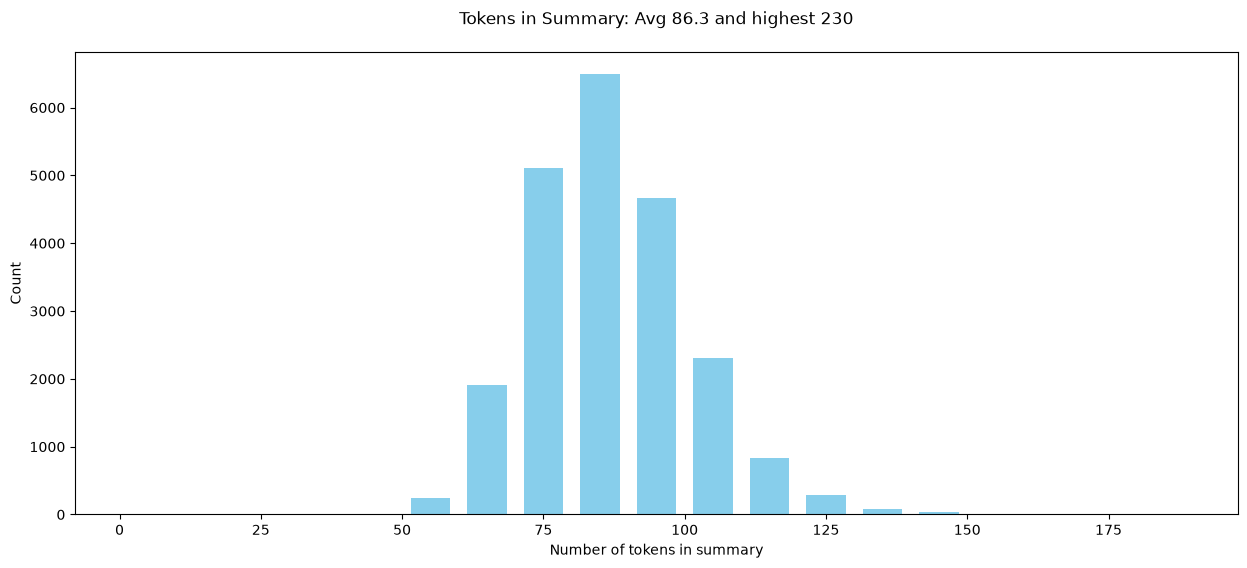

In [6]:
plt.figure(figsize=(15, 6))
plt.title(f"Tokens in Summary: Avg {sum(token_counts)/len(token_counts):,.1f} and highest {max(token_counts):,}\n")
plt.xlabel('Number of tokens in summary')
plt.ylabel('Count')
plt.hist(token_counts, rwidth=0.7, color="skyblue", bins=range(0, 200, 10))
plt.show()

In [19]:
CUTOFF = 110
cut = len([count for count in token_counts if count > CUTOFF])
print(f"With this CUTOFF, we will truncate {cut:,} items which is {cut/len(items):.1%}")

With this CUTOFF, we will truncate 1,139 items which is 5.2%

In [20]:
print(train[0].summary)

Title: Stainless Steel 25mm×100mm Glass Standoff (Pack of 8)  
Category: Hardware & Fixtures  
Brand: uxcell  
Description: A set of 8 stainless steel standoffs for mounting glass panels, signage, or artwork.  
Details: Each standoff measures 25 mm diameter by 100 mm length, featuring a 5 mm hole and 9.5 mm thread for secure
attachment and corrosion resistance.

In [21]:
for item in tqdm(train+val):
    item.make_prompts(tokenizer, CUTOFF, True)
    
for item in tqdm(test):
    item.make_prompts(tokenizer, CUTOFF, False)

  0%|          | 0/21000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [22]:
print(f"Prompt:\n {test[0].prompt}\n")


Prompt:
 What does this cost to the nearest dollar?

Title: Vestil DHHT‑500S Dual‑Handle Steel Hand Truck  
Category: Industrial Hand Trucks  
Brand: Vestil  
Description: A 500‑lb capacity steel hand truck featuring dual handles for superior control.  
Details: Equipped with 10‑inch pneumatic wheels, a 44‑½” height, 22‑½” width, 17‑½” depth, and a 13‑¾”×6‑½” nose 
plate.

Price is $

In [23]:
print(f"Completion:\n {test[0].completion}\n")

Completion:
 144.96

In [24]:
prompt_token_counts = [item.count_prompt_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/22000 [00:00<?, ?it/s]

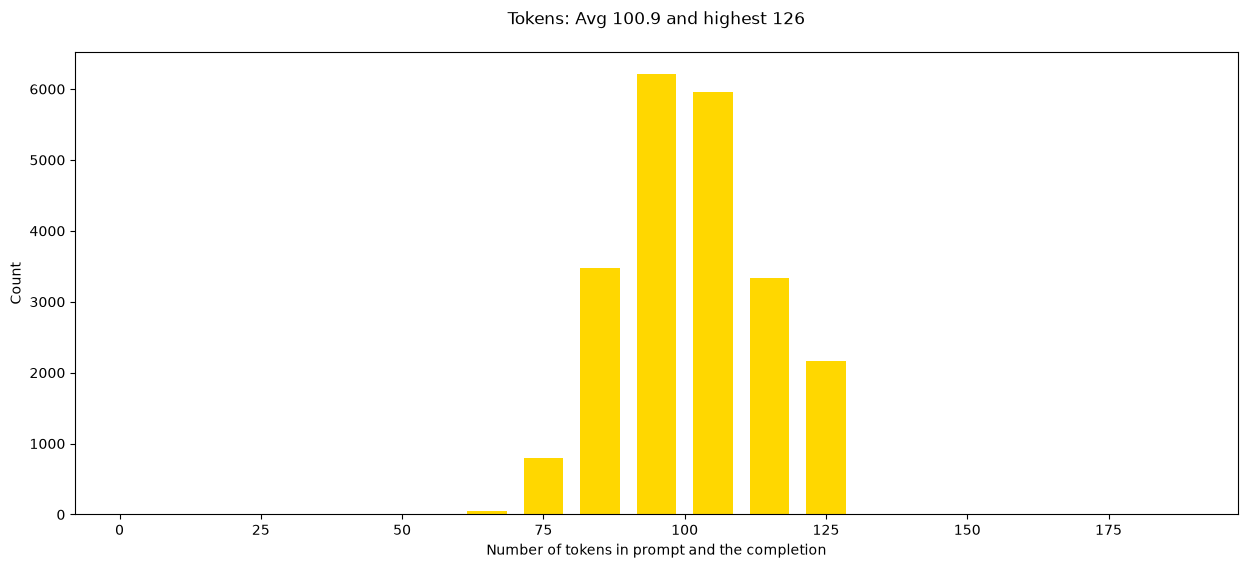

In [25]:
plt.figure(figsize=(15, 6))
plt.title(f"Tokens: Avg {sum(prompt_token_counts)/len(prompt_token_counts):,.1f} and highest {max(prompt_token_counts):,}\n")
plt.xlabel('Number of tokens in prompt and the completion')
plt.ylabel('Count')
plt.hist(prompt_token_counts, rwidth=0.7, color="gold", bins=range(0, 200, 10))
plt.show()

In [26]:
username = "ujjwalsingh108"
dataset = f"{username}/items_prompts_lite" if LITE_MODE else f"{username}/items_prompts_full"

Item.push_prompts_to_hub(dataset, train, val, test)

2026-08-25 18:56:22,029 INFO httpx HTTP Request: GET https://huggingface.co/api/datasets/ujjwalsingh108/items_prompts_lite "HTTP/1.1 404 Not Found"
2026-08-25 18:56:22,743 INFO httpx HTTP Request: POST https://huggingface.co/api/repos/create "HTTP/1.1 200 OK"
Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
2026-08-25 18:56:22,750 WARNING datasets.arrow_dataset Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

2026-08-25 18:56:23,358 INFO httpx HTTP Request: POST https://huggingface.co/api/datasets/ujjwalsingh108/items_prompts_lite/preupload/main "HTTP/1.1 200 OK"


Processing Files (0 / 0): |          |  0.00B /  0.00B            

...

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

2026-08-25 18:56:43,852 INFO httpx HTTP Request: POST https://huggingface.co/api/datasets/ujjwalsingh108/items_prompts_lite/preupload/main "HTTP/1.1 200 OK"


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

2026-08-25 18:56:48,446 INFO httpx HTTP Request: GET https://huggingface.co/api/datasets/ujjwalsingh108/items_prompts_lite "HTTP/1.1 200 OK"
2026-08-25 18:56:48,752 INFO httpx HTTP Request: GET https://huggingface.co/api/datasets/ujjwalsingh108/items_prompts_lite/revision/8fde2005a28013d896e9b335ec6051d9fe2a0548 "HTTP/1.1 200 OK"
2026-08-25 18:56:49,162 INFO httpx HTTP Request: GET https://huggingface.co/api/datasets/ujjwalsingh108/items_prompts_lite/tree/8fde2005a28013d896e9b335ec6051d9fe2a0548/data?recursive=true&expand=false "HTTP/1.1 404 Not Found"
2026-08-25 18:56:49,571 INFO httpx HTTP Request: GET https://huggingface.co/api/datasets/ujjwalsingh108/items_prompts_lite/tree/8fde2005a28013d896e9b335ec6051d9fe2a0548?recursive=false&expand=false "HTTP/1.1 200 OK"
2026-08-25 18:56:50,084 INFO httpx HTTP Request: GET https://huggingface.co/api/datasets/ujjwalsingh108/items_prompts_lite/tree/8fde2005a28013d896e9b335ec6051d9fe2a0548/data?recursive=true&expand=false "HTTP/1.1 404 Not Found